# 03a — Diffusion model training

Train `DiffusionTransformer1D` on the Rolle daily instances using the locked
conditioning design from notebook 02 §8b.1:

```
c_discrete   = [cluster_id, day_type, season]            # 3 channels, AdaLN
c_continuous = [temp_normed, log_mean_z, log_std_z]      # 3 channels, cross-attention
```

Data loading, train/val split, and the sanity-panel layout are identical to
[03_benchmark.ipynb](03_benchmark.ipynb) so the resulting metrics are
directly comparable to the historical baseline floor (val MAE ≈ 15.4 kW).


In [1]:
import sys, os, pathlib, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp, equinox as eqx

from src.data.loader   import load_rolle_data, compute_temp_stats, normalize_temp
from src.data.dataset  import (make_daily_instances, train_val_split_instances,
                               numpy_dataloader)
from src.models.diffusion     import DiffusionProcess
from src.models.transformer1d import DiffusionTransformer1D
from src.training.train       import Trainer
from src.runtime_paths        import DATA_DIR, OUTPUT_DIR

# ----- Runtime profile ---------------------------------------------------
# Toggle GPU=True on Colab / a real accelerator for a full training run.
# GPU=False is a fast sanity check that still exercises every code path.
GPU = bool(int(os.environ.get("TESINA_GPU", "0")))
try:
    _dev0 = jax.devices()[0].platform
except Exception:
    _dev0 = "cpu"
if not GPU and _dev0 in ("gpu", "tpu"):
    GPU = True   # auto-upgrade when an accelerator is actually present
print(f"[runtime] jax device = {_dev0!r}  GPU profile = {GPU}")

RANDOM_SEED  = 42
VAL_FRACTION = 0.15
BATCH_SIZE   = 128 if GPU else 64


ERROR:2026-05-28 16:06:21,737:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nicola/Desktop/Supsi/tesina/.venv/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nicola/Desktop/Supsi/tesina/.venv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nicola/Desktop/Supsi/tesina/.venv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


[runtime] jax device = 'cpu'  GPU profile = False


## 1. Load data and the locked 6-channel conditioning vector

Mirror of `03_benchmark.ipynb` §1 — merges `clusters.csv` and
`daily_covariates.csv` into the dataset returned by `make_daily_instances`.


In [ ]:
from src.data.dataset import shape_normalize, split_mask_by_meter
from src.data.loader  import invert_scale_z
import json as _json

power_df, temp_daily = load_rolle_data(DATA_DIR)
temp_stats  = compute_temp_stats(temp_daily)
temp_normed = normalize_temp(temp_daily, temp_stats)

df_cl  = pd.read_csv(pathlib.Path(DATA_DIR) / 'clusters.csv')
df_cov = pd.read_csv(pathlib.Path(DATA_DIR) / 'daily_covariates.csv')
cl_lookup  = {(int(r.meter_id), r.date): int(r.cluster_id)
              for _, r in df_cl.iterrows()}
cov_lookup = {(int(r.meter_id), r.date):
              (float(r.temp_normed), float(r.log_mean_z), float(r.log_std_z))
              for _, r in df_cov.iterrows()}

# Scale stats (saved by notebook 02 §9) — needed to invert the global z-score
# applied to log_mean / log_std, which in turn allows shape_denormalize() to
# map generated profiles back to Watts at evaluation time.
scale_stats = _json.loads((pathlib.Path(DATA_DIR) / 'scale_stats.json').read_text())

xs, c_disc, c_cont1, dates, meter_ids = make_daily_instances(
    power_df, temp_normed, cluster_labels=cl_lookup
)

# Per-instance shape normalisation (see notebook 01 §9 for rationale): the
# model learns scale-free shape; raw amplitude is recovered at inference
# from the (log_mean_z, log_std_z) channels of c_continuous.
xs, log_mean, log_std = shape_normalize(xs)

# Build the 3-channel continuous conditioning, aligned to instance order.
c_cont = np.zeros((len(xs), 3), dtype=np.float32)
for i, (m, d) in enumerate(zip(meter_ids, dates)):
    c_cont[i] = cov_lookup[(int(m), str(d))]

N_METERS   = int(meter_ids.max()) + 1
N_CLUSTERS = int(c_disc[:, 0].max()) + 1
print(f'Instances        : {len(xs):,}')
print(f'c_discrete shape : {c_disc.shape}  (cluster_id, day_type, season)')
print(f'c_continuous     : {c_cont.shape}  (temp_normed, log_mean_z, log_std_z)')
print(f'xs (normalised)  : {xs.shape}  '
      f'mean={xs.mean():+.2e}  std={xs.std():.3f}')
print(f'N_CLUSTERS       : {N_CLUSTERS}   N_METERS: {N_METERS}')

# Local-profile subsample: keeps the smoke test fast on CPU but still
# covers all clusters/seasons. Skipped under the GPU profile. The
# per-instance scales (log_mean, log_std) are subsampled in lock-step so
# they remain aligned with the surviving xs rows.
if not GPU:
    SUBSAMPLE_N = 1_000
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(xs), size=min(SUBSAMPLE_N, len(xs)), replace=False)
    xs, c_disc, c_cont = xs[idx], c_disc[idx], c_cont[idx]
    dates, meter_ids   = dates[idx], meter_ids[idx]
    log_mean, log_std  = log_mean[idx], log_std[idx]
    print(f'[local profile] subsampled to {len(xs):,} instances')


Instances        : 8,928
c_discrete shape : (8928, 3)  (cluster_id, day_type, season)
c_continuous     : (8928, 3)  (temp_normed, log_mean_z, log_std_z)
N_CLUSTERS       : 5   N_METERS: 24
[local profile] subsampled to 1,000 instances


## 2. Train / val split + dataloaders

Same split as the benchmark (seed=42, val_fraction=0.15).


In [ ]:
x_tr, cd_tr, cc_tr, mid_tr, x_val, cd_val, cc_val, mid_val = train_val_split_instances(
    xs, c_disc, c_cont, meter_ids,
    n_meters=N_METERS, val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
)

# Reproduce the same partition for the per-instance log scales so we can
# denormalise the val set back to Watts later.
val_mask = split_mask_by_meter(meter_ids, n_meters=N_METERS,
                               val_fraction=VAL_FRACTION, seed=RANDOM_SEED)
log_mean_tr, log_std_tr   = log_mean[~val_mask], log_std[~val_mask]
log_mean_val, log_std_val = log_mean[val_mask],  log_std[val_mask]
print(f'Train: {len(x_tr):,}   Val: {len(x_val):,}')

train_loader = numpy_dataloader(x_tr, cd_tr, BATCH_SIZE,
                                c_continuous=cc_tr, shuffle=True)
val_loader   = numpy_dataloader(x_val, cd_val, BATCH_SIZE,
                                c_continuous=cc_val, shuffle=False)


Train: 823   Val: 177


## 3. Build model and diffusion process

`n_continuous=3` so the model instantiates one linear projection per
continuous channel (the model already supports arbitrary widths).


In [4]:
key   = jax.random.PRNGKey(0)
model = DiffusionTransformer1D(
    seq_len=24, d_model=128, n_heads=4, n_layers=4, d_ff=256,
    n_clusters=N_CLUSTERS, n_day_types=2, n_seasons=4,
    n_continuous=c_cont.shape[1],     # 3
    key=key,
)
diffusion = DiffusionProcess(T=1000)
params = sum(p.size for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f'Model parameters: {params:,}')


Model parameters: 1,106,274


## 4. Train

Standard score-matching objective $\mathcal{L}=\mathbb{E}_{t,\epsilon}\|\epsilon - \hat\epsilon_\theta(x_t, t, c)\|^2$
with CFG dropout (`p_uncond=0.15`) so the same checkpoint can be used both
conditionally and unconditionally at sampling time.

Two runtime profiles are supported:

| profile        | when                          | steps  | epochs | warmup | patience |
|----------------|-------------------------------|--------|--------|--------|----------|
| **`GPU=False`**| local sanity check (CPU)      | 2 000  | 3      | 50     | 3        |
| **`GPU=True`** | Colab / accelerator (full run)| 100 000| 100    | 500    | 20       |

Set the env var `TESINA_GPU=1` (or edit the flag in §0) to switch.


In [5]:
ckpt_dir = pathlib.Path(OUTPUT_DIR) / '03a' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
# Hyper-parameters scale with the runtime profile.
if GPU:
    TOTAL_STEPS, N_EPOCHS, WARMUP, PATIENCE = 100_000, 100, 500, 20
else:
    # Local CPU smoke test — completes in a couple of minutes.
    TOTAL_STEPS, N_EPOCHS, WARMUP, PATIENCE = 2_000, 3, 50, 3

trainer = Trainer(
    model=model, diffusion=diffusion,
    lr=5e-4, warmup_steps=WARMUP, total_steps=TOTAL_STEPS,
    checkpoint_dir=str(ckpt_dir), p_uncond=0.15, seed=0,
)

trainer.fit(
    train_loader, val_loader,
    n_epochs=N_EPOCHS, val_every=5, save_every=10,
    log_every_steps=200, val_batches=20,
    patience=PATIENCE,
)

# Persist the final model so notebooks 04/05 can load it.
trainer.save('best_model.pkl')


Epoch   1/3  train_loss 111.9418  [47.9s]  [C0=103.2940  C1=174.6725  C2=57.5396  C3=52.5238  C4=110.0124]
Epoch   2/3  train_loss 29.8895  [4.8s]  [C0=27.1513  C1=51.1518  C2=12.9923  C3=18.7514  C4=25.8625]
Epoch   3/3  train_loss 7.2658  [6.9s]  [C0=4.7872  C1=10.0858  C2=5.2261  C3=4.0415  C4=6.1721]


## 5. Training curves

Both train and val curves are plotted against epoch index. Validation is
computed every 5 epochs, so on the local profile (`n_epochs=3`) the val
trace is empty by design — it only populates under the GPU profile.


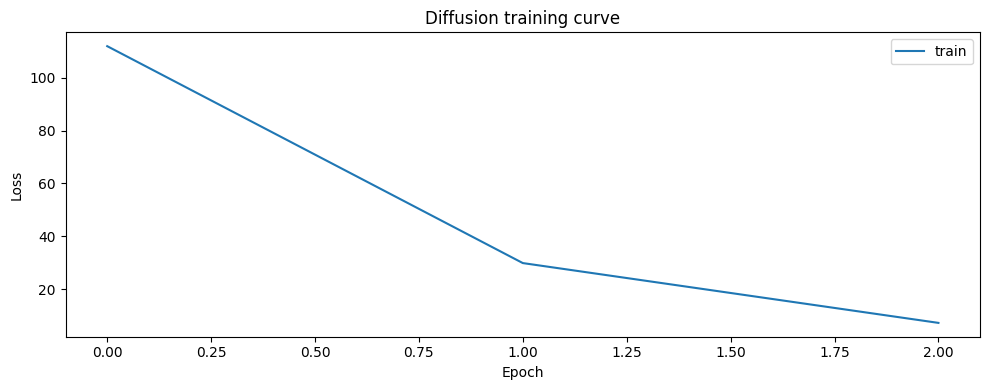

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(trainer.train_losses, label='train')
if trainer.val_losses:
    xs_val = [i * 5 for i in range(len(trainer.val_losses))]
    plt.plot(xs_val, trainer.val_losses, label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Diffusion training curve'); plt.tight_layout(); plt.show()


## 6. Sanity-check panel — all clusters × 4 day/season conditions

Grid: rows = clusters (0–4) · columns = (weekday/weekend) × (winter/summer).
Each panel shows a few validation instances paired with the model's sample
generated for the **same** continuous condition (temp\_normed, log\_mean\_z, log\_std\_z).

* **Same colour** → same meter (real vs model sample share the same query)
* **Solid line** → real profile from that meter on that day
* **Dashed line** → diffusion sample for that meter's condition

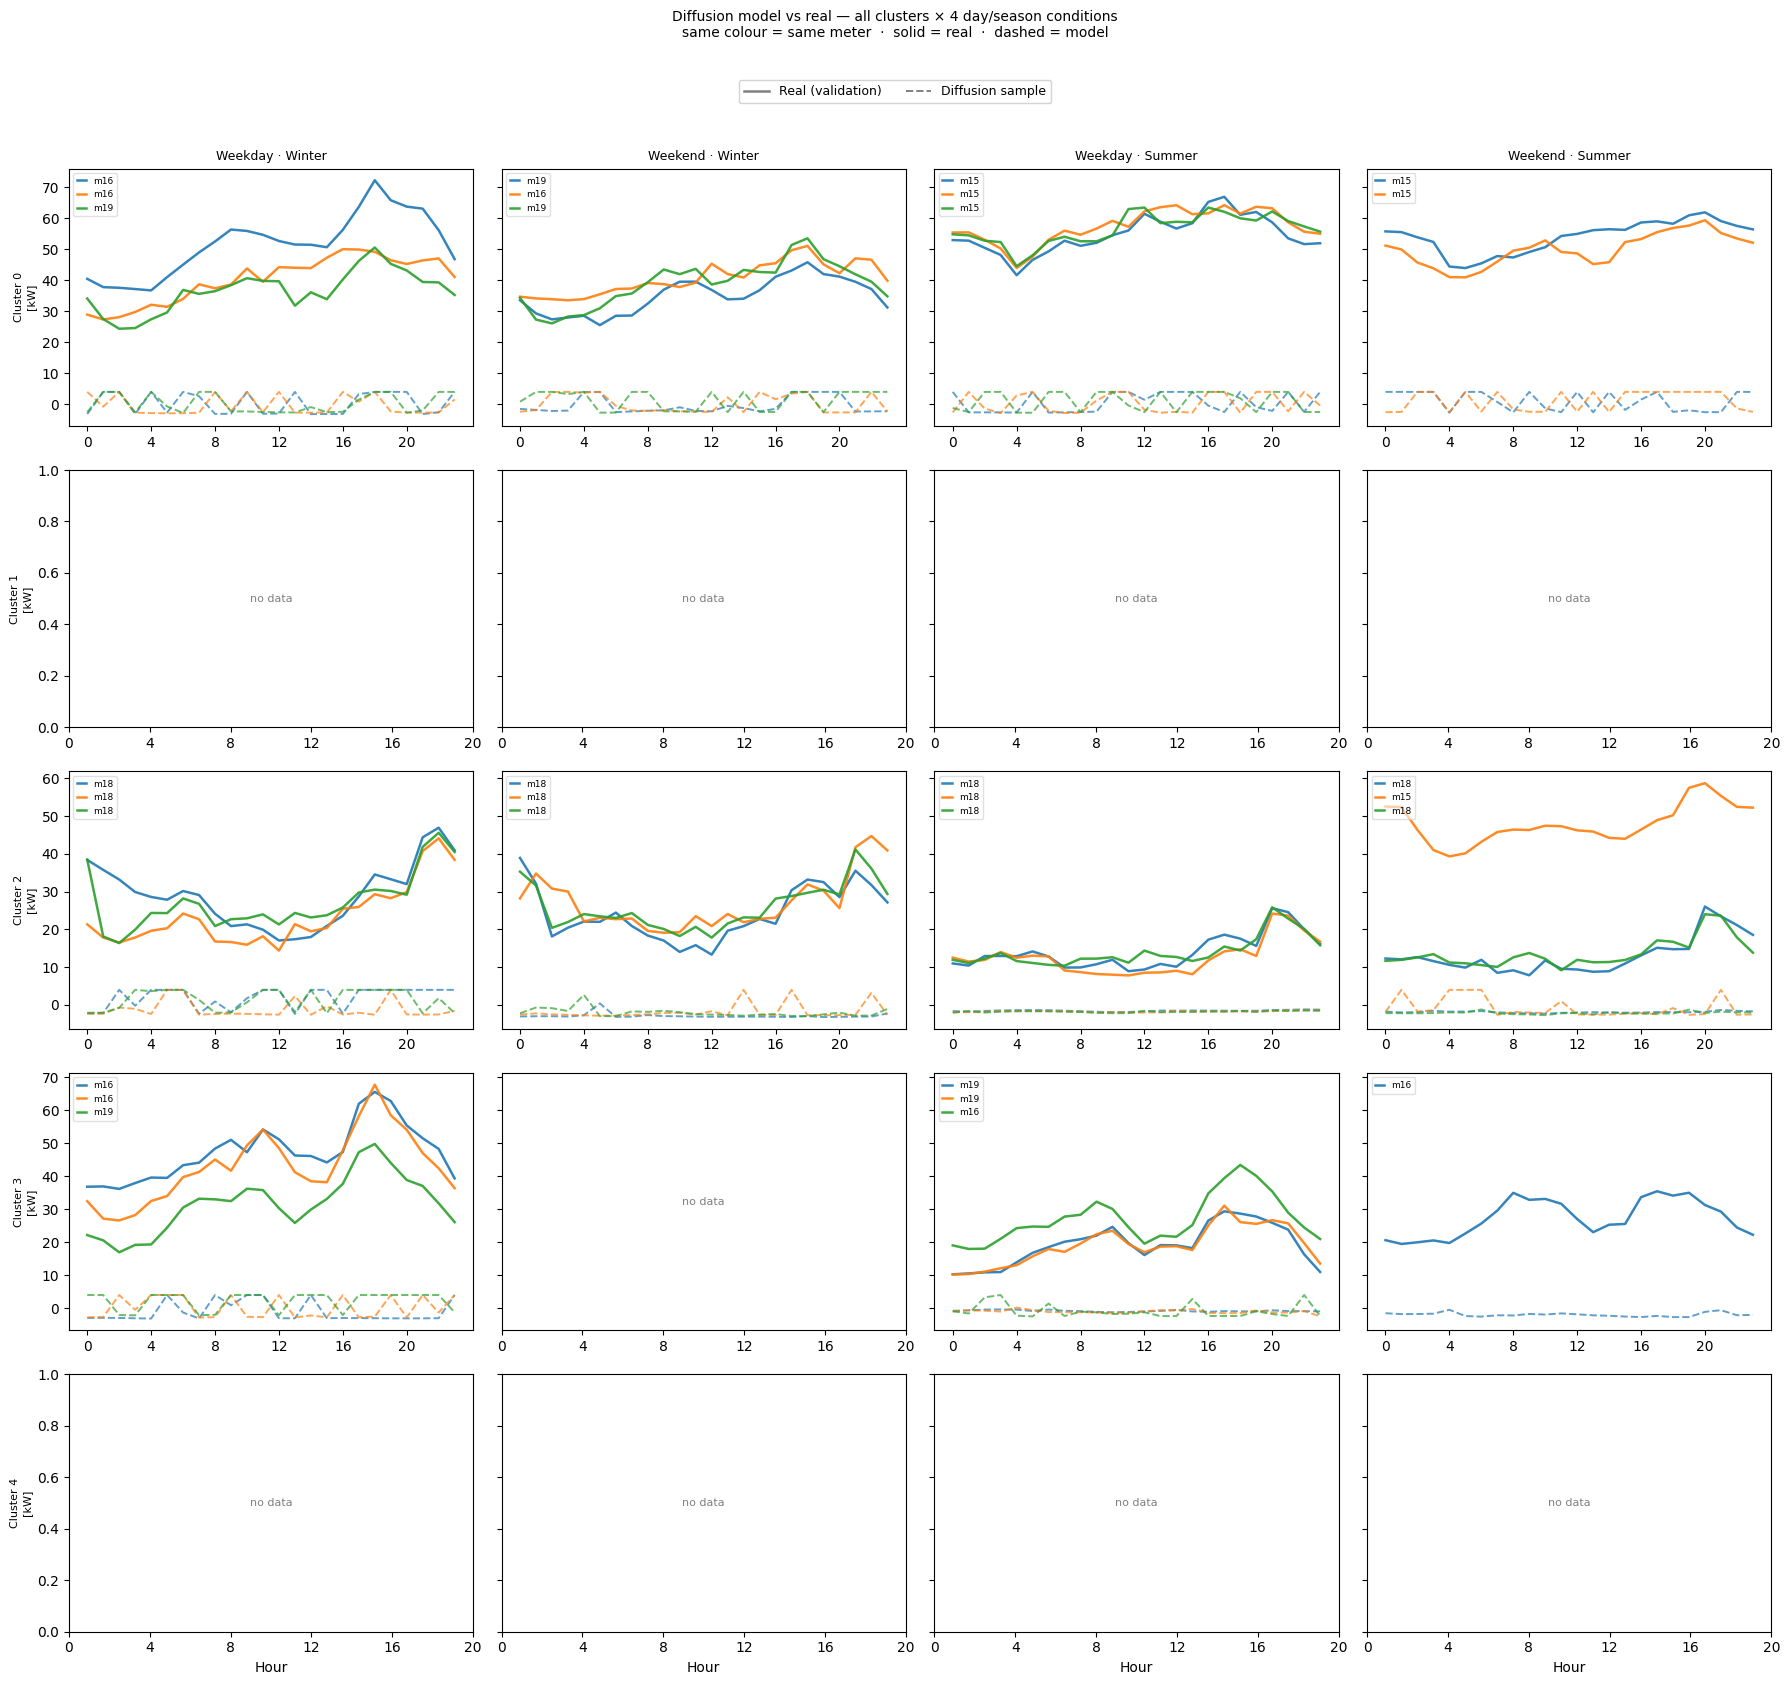

In [ ]:
from matplotlib.lines import Line2D
from src.data.dataset import shape_denormalize

hours    = np.arange(24)
n_sample = 3
key_smp  = jax.random.PRNGKey(123)

day_season_specs = [
    (0, 0, 'Weekday · Winter'),
    (1, 0, 'Weekend · Winter'),
    (0, 2, 'Weekday · Summer'),
    (1, 2, 'Weekend · Summer'),
]

n_rows = N_CLUSTERS
n_cols = len(day_season_specs)
pair_colors = plt.cm.tab10(np.arange(n_sample))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.2 * n_rows),
    sharey='row',
)

for row, cid in enumerate(range(N_CLUSTERS)):
    for col, (dt, season, cond_label) in enumerate(day_season_specs):
        ax = axes[row, col]
        mask = (cd_val[:, 0] == cid) & (cd_val[:, 1] == dt) & (cd_val[:, 2] == season)

        if row == 0:
            ax.set_title(cond_label, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'Cluster {cid}\n[W]', fontsize=8)
        ax.set_xticks(hours[::4])
        if row == n_rows - 1:
            ax.set_xlabel('Hour')

        if not mask.any():
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey')
            continue

        idx    = np.where(mask)[0]
        chosen = np.random.default_rng(RANDOM_SEED + row * 100 + col).choice(
            idx, size=min(n_sample, len(idx)), replace=False
        )

        # Generate one diffusion sample per chosen instance using its exact cc condition.
        cd_q = jnp.tile(jnp.array([cid, dt, season], dtype=jnp.int32), (len(chosen), 1))
        cc_q = jnp.asarray(cc_val[chosen], dtype=jnp.float32)   # (n_chosen, 3)
        key_smp, sub = jax.random.split(key_smp)
        gen_norm = np.asarray(diffusion.ddim_sample(
            trainer.model, cd_q, cc_q,
            seq_len=24, batch_size=len(chosen), key=sub,
            n_steps=50, guidance_scale=2.0,
        ))

        # Denormalise both real and generated to Watts so the plot is
        # interpretable. Per-instance scales come from the val arrays
        # (real) and from the queried cc rows (generated); by construction
        # they coincide here.
        lm_q, ls_q = invert_scale_z(np.asarray(cc_q[:, 1]),
                                    np.asarray(cc_q[:, 2]), scale_stats)
        real_W = shape_denormalize(x_val[chosen],
                                   log_mean_val[chosen], log_std_val[chosen])
        gen_W  = shape_denormalize(gen_norm, lm_q, ls_q)

        for k, ci in enumerate(chosen):
            mid   = int(mid_val[ci])
            color = pair_colors[k]
            ax.plot(hours, real_W[k],
                    color=color, linewidth=1.8, linestyle='-', alpha=0.9,
                    label=f'm{mid}')
            ax.plot(hours, gen_W[k],
                    color=color, linewidth=1.4, linestyle='--', alpha=0.7,
                    label='_nolegend_')

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=6.5, loc='upper left',
                  framealpha=0.6, ncol=1, handlelength=1.0)

style_legend = [
    Line2D([0], [0], color='grey', linewidth=1.8, linestyle='-',
           label='Real (validation)'),
    Line2D([0], [0], color='grey', linewidth=1.4, linestyle='--',
           label='Diffusion sample'),
]
fig.legend(handles=style_legend, loc='upper center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, 1.01), framealpha=0.85)

plt.suptitle(
    'Diffusion model vs real (denormalised to Watts) — all clusters × 4 day/season conditions\n'
    'same colour = same meter  ·  solid = real  ·  dashed = model',
    fontsize=10, y=1.05,
)
plt.tight_layout()
plt.show()


## 7. Save training summary

Dump a small JSON record so downstream notebooks (04, 05) can pick up the
checkpoint along with the conditioning schema, the runtime profile and the
final losses, without having to re-derive them. Same field set across
03a / 03b / 03c → keeps the comparison clean.


In [8]:
results_dir = pathlib.Path(OUTPUT_DIR) / '03a' / 'results' / 'diffusion'
results_dir.mkdir(parents=True, exist_ok=True)
summary_path = results_dir / 'training_summary.json'

summary = {
    'model'         : 'DiffusionTransformer1D',
    'parametric'    : True,
    'train_instances': int(len(x_tr)),
    'val_instances' : int(len(x_val)),
    'n_clusters'    : int(N_CLUSTERS),
    'gpu_profile'   : bool(GPU),
    'total_steps'   : int(TOTAL_STEPS),
    'n_epochs_cap'  : int(N_EPOCHS),
    'c_discrete'    : ['cluster_id', 'day_type', 'season'],
    'c_continuous'  : ['temp_normed', 'log_mean_z', 'log_std_z'],
    'n_parameters'  : int(params),
    'batch_size'    : BATCH_SIZE,
    'final_train_loss': float(trainer.train_losses[-1]) if trainer.train_losses else None,
    'final_val_loss'  : float(trainer.val_losses[-1])   if trainer.val_losses   else None,
    'random_seed'   : RANDOM_SEED,
    'val_fraction'  : VAL_FRACTION,
}
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved → {summary_path}')
print(json.dumps(summary, indent=2))


Saved → /home/nicola/Desktop/Supsi/tesina/output/03a/results/diffusion/training_summary.json
{
  "model": "DiffusionTransformer1D",
  "parametric": true,
  "train_instances": 823,
  "val_instances": 177,
  "n_clusters": 5,
  "gpu_profile": false,
  "total_steps": 2000,
  "n_epochs_cap": 3,
  "c_discrete": [
    "cluster_id",
    "day_type",
    "season"
  ],
  "c_continuous": [
    "temp_normed",
    "log_mean_z",
    "log_std_z"
  ],
  "n_parameters": 1106274,
  "batch_size": 64,
  "final_train_loss": 7.265836536884308,
  "final_val_loss": null,
  "random_seed": 42,
  "val_fraction": 0.15
}
